### PROJECT 1: NETFLIX CONTENT ANALYSIS

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

When I have a dataset in hand, I want to assume a role so I can think more clearly what I am looking for, what to expect. With this one I decided to take the role of a Digital Marketing Specialist who wants to know which content is working best in the platform, to create a related campaign. How is it related? Well if you know the type of content that works, it could lead you to know the type of audience you reach the most so the campaigns can be more directed. Also knowing the duration could be an indicator of the engagement etc. So those are the questios I'll be trying to answer in this project.


In [16]:
# Load the dataset
df = pd.read_csv('../data/raw/netflix_titles.csv')

In [17]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


We can see that there are no null values so the next step is see if there is any NA values.

In [19]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Given the results, the obvious next step will be see what type of values are and if they suppose a significant amount for our analysis. For now, I won't be using the column director so there is no need to do anything to those lines so we move to the next. Cast is also a column I won't be using but 'country' is. The thing is 831 NA values of the  the 8.807 I have seem meaningless so I won't take any further actions. Just fill them with the tag "Unknown".

In [20]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")

In [21]:
df = df.drop_duplicates()

In [22]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [23]:
df.nunique()

show_id         8807
type               2
title           8807
director        4529
cast            7693
country          749
date_added      1767
release_year      74
rating            18
duration         220
listed_in        514
description     8775
dtype: int64

Now, with what I have left I must start deciding which columns can help me get the insights I am looking for. 

# MOVIES VS TV SHOWS

First I want to see if the platform has more movies or TV shows.

C:\Users\pc\AppData\Local\Temp\ipykernel_6960\23678575.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


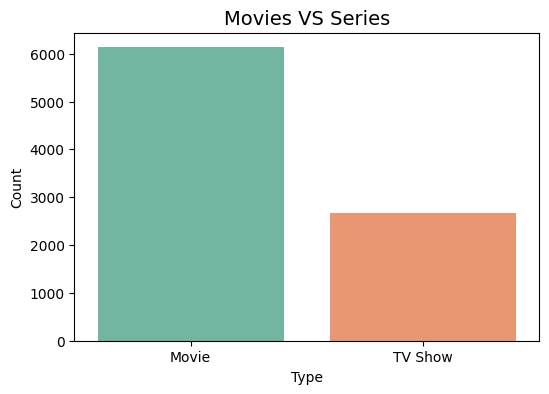

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df, palette='Set2')
plt.title("Movies VS Series", fontsize=14)
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

Based on this dataset, Netflix has more than the double of movies than TV shows.

# WHICH COUNTRIES HAVE THE MORE TITLES IN THE PLATFORM

Now, which countries have more titles? This could tell us a few things, there are countries that produce more content, Netflix has more access to content from certain countries, the public tend to like more content from some countries etc.

C:\Users\pc\AppData\Local\Temp\ipykernel_6960\2346143021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


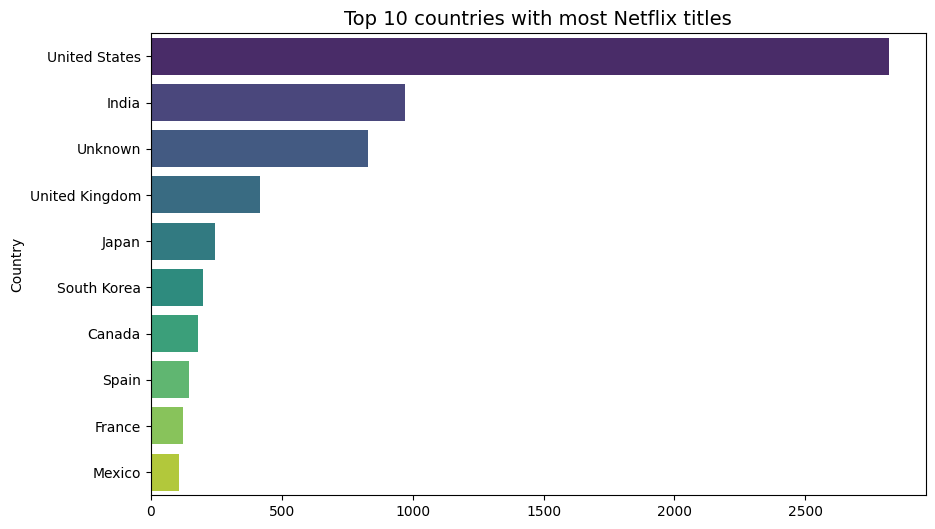

In [25]:
plt.figure(figsize=(10,6))
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title("Top 10 countries with most Netflix titles", fontsize=14)
plt.ylabel("Country")
plt.show()

The graph shows that the third country with more titles is unknown which is important because they could add to other countries. It would be important to investigate further. 

# FROM WHAT YEAR ARE MOST OF THE RELEASES?

This is not about how many movies are being produced right now is more about variety. To see if the platform focuses on modern movies or also has movies from before the platform appeared. This because even if Netflix is known for having the latest shows and movies, the user now has changed from TV to streaming services so not only you want to watch new content but also go to the classics and older material. 

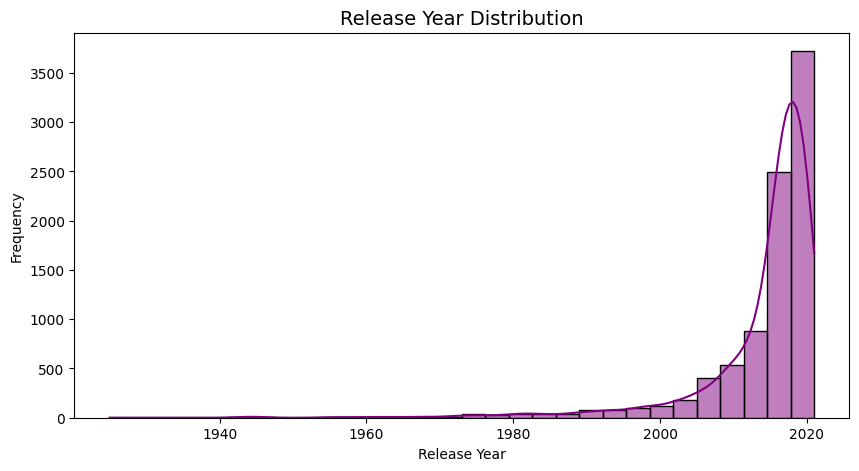

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=30, color='purple', kde=True)
plt.title("Release Year Distribution", fontsize=14)
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

Seems like most of the content was released from 2010 on.

# WHAT GENRES ARE THE MOST COMMON?

I must note that this shows what kind of content is the most present in Netflix, doesn't mean is the most liked because we lack that information. A good next step would be complement this analysis with other datasets with that type of information. 

C:\Users\pc\AppData\Local\Temp\ipykernel_6960\985768510.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')


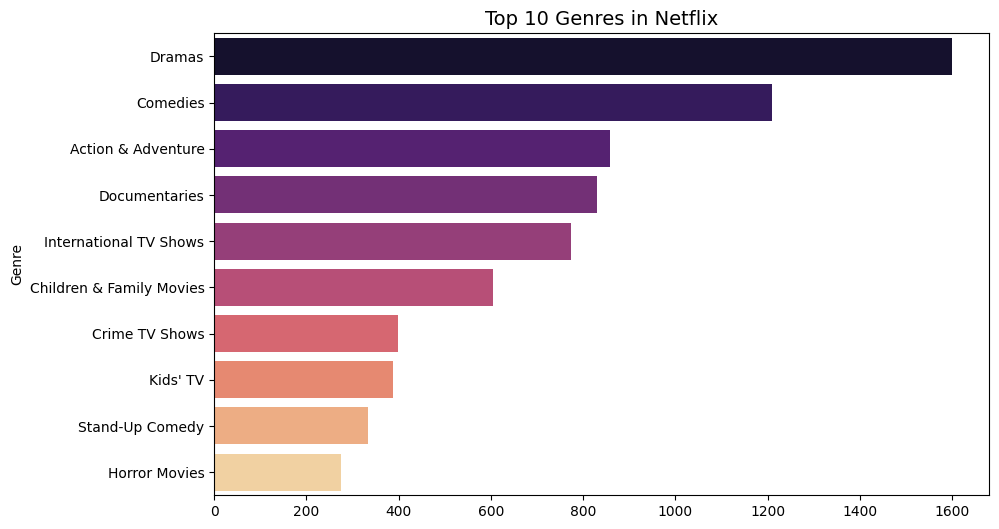

In [30]:
plt.figure(figsize=(10,6))
df['main_genre'] = df['listed_in'].str.split(',').str[0]
top_genres = df['main_genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title("Top 10 Genres in Netflix", fontsize=14)
plt.ylabel("Genre")
plt.show()

# MOVIES VS TV SHOWS ADDED OVER TIME

Given the column data_added I built the column year_added mostly to group for years and not having a lot of different sections.

C:\Users\pc\AppData\Local\Temp\ipykernel_6960\2626699796.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'])


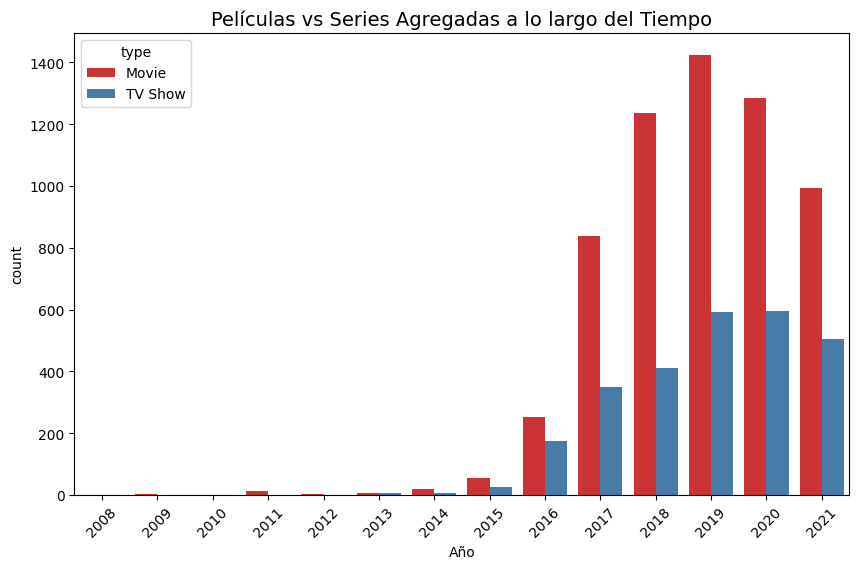

In [28]:

df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year.astype('Int64')

plt.figure(figsize=(10,6))
sns.countplot(x='year_added', hue='type', data=df, palette='Set1')
plt.xticks(rotation=45)
plt.title("Movies vs Series Added Over Time", fontsize=14)
plt.xlabel("Year Added")
plt.show()

The fact that more movies are added than series could be a result that commonly series have been aired on TV before the take over of the streaming services. The curious thing here is they both seem to have the same tendencies, if they add more they add more of both and viceversa. 

# WHAT DO THE RATINGS SAY?

Here is the interesting thing, this graph not only does it show us the ratings of most of the content, but it also gives us an idea of the age of most users. This from a digital marketing perspective is quite insightful. 

C:\Users\pc\AppData\Local\Temp\ipykernel_6960\2209465623.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


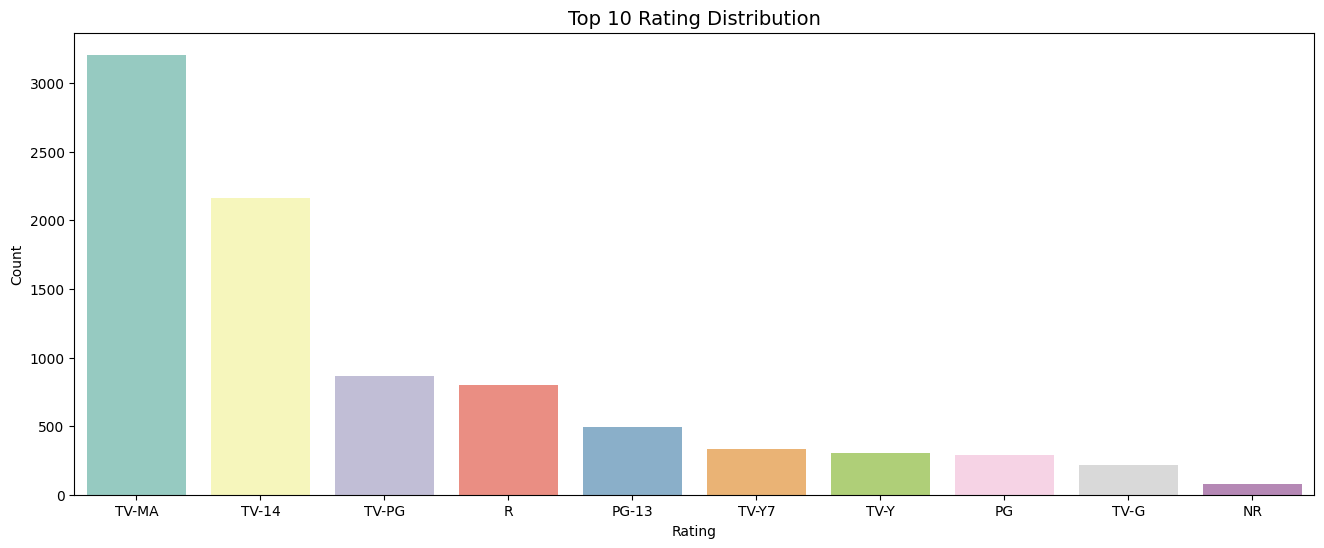

In [37]:
top_10_ratings = df['rating'].value_counts().head(10).index

plt.figure(figsize=(16,6))
sns.countplot(
    x='rating',
    data=df,
    palette='Set3',
    order=top_10_ratings
)

plt.title("Top 10 Rating Distribution", fontsize=14)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

- TV-MA: Mature Audience Only. This program is specifically designed to be viewed by adults and therefore may be unsuitable for children under 17.
- TV-14: This program contains materia that many parents would find unsuitable for children under 14 years of age.
- TV-PG: This program contains material that parents may find unsuitable for younger children.
- R: Restricted. Under 17 requires accompanying parent or adult guardian. Contains some adult material.
- PG-13: Parents Strongly Cautiones. Some material may be inappropiate for children under 13. 
- TV-Y7: This program is designed for children age 7 and above. 
- PG: Parental Guidence Suggested. Some material may not be suitable for children.
- TV-G: Most parents will find this program suitable for all ages. 
- NR: Not Rated

# ANALYZING THE DURATION OF THE CONTENT

Analyzing the duration of movies or TV shows is useful because it helps understand both viewer behaviou and content strategy.

Different durations attract different audiences and viewing habits.

For example:

- Short movies → easier casual viewing
- Long movies → more cinematic/premium experiences
- Short TV seasons → binge-friendly
- Long TV series → higher platform retention

This helps identify what type of content Netflix prioritizes.
Also, most industries have in common duration ranges, this way we can study if Netflix follows the industry standards or differs strategically. 
Between other things, duration directly impacts:

- watch time,
- user retention,
- binge behavior,
- completion rates.

So... 
- Are TV shows becoming shorter?
- Does Netflix favor mini-series?
- Are movies getting longer over time?
- Which format dominates engagement?

In [38]:
# Extraer número de duration
df['duration_num'] = pd.to_numeric(
    df['duration'].astype(str).str.extract(r'(\d+)', expand=False),
    errors='coerce'
)

# Movies → minutos
df.loc[df['type'] == 'Movie', 'duration_minutes'] = df['duration_num']

# TV Shows → temporadas
df.loc[df['type'] == 'TV Show', 'seasons'] = df['duration_num']

# Duration ranges
bins = [0, 60, 90, 120, 150, 300]
labels = ['< 60 min', '60-90 min', '90-120 min', '120-150 min', '150+ min']

df['duration_movies'] = pd.cut(
    df['duration_minutes'],
    bins=bins,
    labels=labels
)

df['duration_tv_shows'] = pd.cut(
    df['seasons'],
    bins=[0, 1, 3, 5, 10],
    labels=['< 1 season', '1-3 seasons', '4-5 seasons', '6+ seasons']   
)


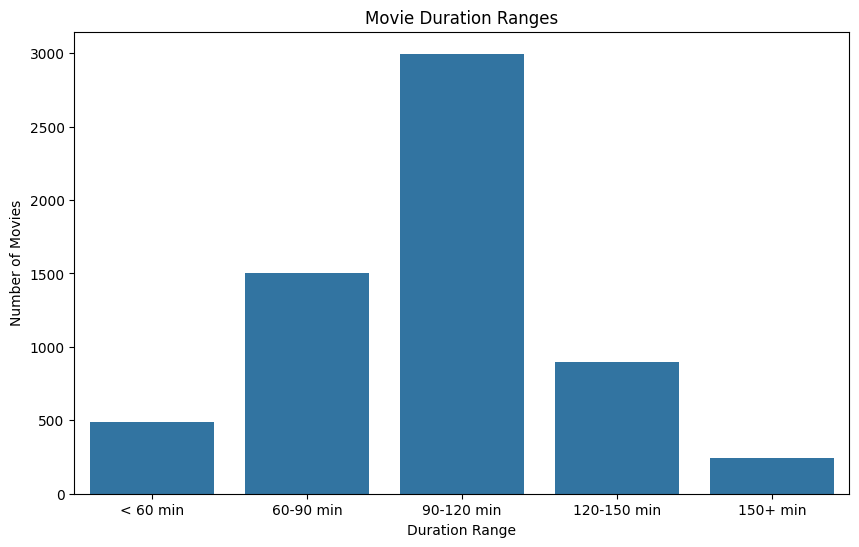

In [39]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='duration_movies',
    order=[
        '< 60 min',
        '60-90 min',
        '90-120 min',
        '120-150 min',
        '150+ min'
    ]
)

plt.title('Movie Duration Ranges')
plt.xlabel('Duration Range')
plt.ylabel('Number of Movies')

plt.show()

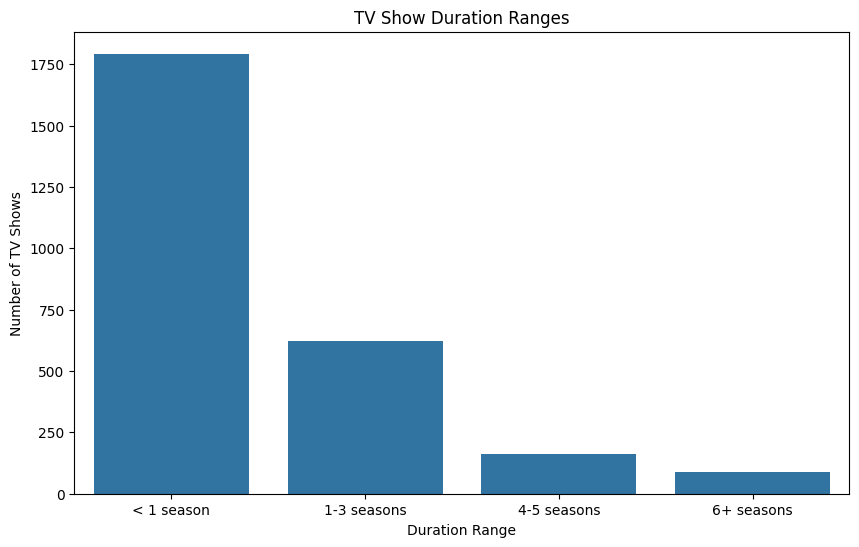

In [40]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='duration_tv_shows',
    order=['< 1 season', 
           '1-3 seasons', 
           '4-5 seasons', 
           '6+ seasons'] 
    
)

plt.title('TV Show Duration Ranges')
plt.xlabel('Duration Range')
plt.ylabel('Number of TV Shows')

plt.show()

Most Netflix movies fall within the 90–120 minute range, suggesting the platform follows traditional feature-film standards while optimizing for viewer accessibility and completion rates.